<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>למידה סטטיסטית 99218</p>
<p>מטלת בית 2</p>

<p>שם: נדב פיירמן שטרן</p>

</div>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import combinations
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import KFold, LeaveOneOut, cross_val_score
from sklearn.linear_model import (Lasso, LassoCV, ElasticNet, ElasticNetCV, LogisticRegression, LogisticRegressionCV,)

%matplotlib inline
plt.style.use('ggplot')
pd.set_option('display.float_format', lambda x: '%.4f' % x)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
path = '/content/drive/MyDrive/Statistical Learning/HW2'
for f in os.listdir(path):
    print(f)

haifa_res.csv
Homework 2 - Stat Learn.pdf
psych_data.txt
titanic.csv
Statistical Learning HW2.ipynb


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 1</p>

<p>השתמש בקובץ haifa_res.xls. התאם מודל ליניארי של ההוצאה החודשית כפונקציה של ההכנסה החודשית המובחנת לפי מין. שקול גם משתנה אינדיקטור למין וגם איבר אינטראקציה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 1 א.</p>

<p>הצג את המודל התיאורטי ופרט את ההנחות. הצג מודל מותאם ואת הסיכום שלו. האם המודל מובהק?</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>המודל התיאורטי כולל משתנה אינדיקטור למין ואיבר אינטראקציה בין הכנסה למין:</p>

$$Y_i = \beta_0 + \beta_1 X_i + \beta_2 D_i + \beta_3 (X_i \cdot D_i) + \epsilon_i$$

<p>כאשר $X_i$ הכנסה חודשית ו-$D_i = 1$ אם גבר, $D_i = 0$ אם אישה. המודל מתפרק לשתי משוואות:</p>

<ul>
<li>נשים: $Y_i = \beta_0 + \beta_1 X_i + \epsilon_i$</li>
<li>גברים: $Y_i = (\beta_0 + \beta_2) + (\beta_1 + \beta_3) X_i + \epsilon_i$</li>
</ul>

<p>הנחות המודל:</p>
<ol type="a">
<li>נורמליות — $\epsilon_i \sim N(0, \sigma^2)$ לכל $i$</li>
<li>שוויון שונויות — $\text{Var}(\epsilon_i) = \sigma^2$ קבוע</li>
<li>עצמאות — $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ לכל $i \neq j$</li>
<li>לינאריות — הקשר בין ההכנסה להוצאות לינארי בפרמטרים</li>
</ol>

</div>

In [ ]:
df = pd.read_csv(os.path.join(path, 'haifa_res.csv'))

model = smf.ols('spend ~ income + sex + income:sex', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     174.0
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.33e-55
Time:                        08:34:11   Log-Likelihood:                -362.83
No. Observations:                 200   AIC:                             733.7
Df Residuals:                     196   BIC:                             746.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0283      0.520      0.055      0.9

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>המודל האמוד:</p>

$$\hat{Y}_i = 0.028 + 0.989 X_i - 0.971 D_i + 0.119 (X_i \cdot D_i)$$

<p>מובהקות המודל:</p>
<ul>
<li>$F(3, 196) = 174.0$, $p < 10^{-54}$ — המודל מובהק מאוד.</li>
<li>$R^2 = 0.727$ — המודל מסביר כ-72.7% מהשונות בהוצאות.</li>
</ul>

<p>פרשנות המקדמים:</p>
<ul>
<li>$\hat{\beta}_1 = 0.989$ — כל אלף ש"ח הכנסה נוספת מגדילה את ההוצאה ב-989 ש"ח אצל נשים. מובהק ($p < 0.001$).</li>
<li>$\hat{\beta}_2 = -0.971$ — הפרש החותך בין גברים לנשים. לא מובהק ($p = 0.212$).</li>
<li>$\hat{\beta}_3 = 0.119$ — הפרש השיפוע בין גברים לנשים. לא מובהק ($p = 0.198$).</li>
</ul>

<p>המסקנה: ההכנסה מסבירה היטב את ההוצאות, אך לא נמצא הבדל מובהק בין גברים לנשים לא בחותך ולא בשיפוע.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 1 ב.</p>

<p>שרטט את התוצאות (שורה אחת לגברים ואחרת לנשים).</p>

</div>

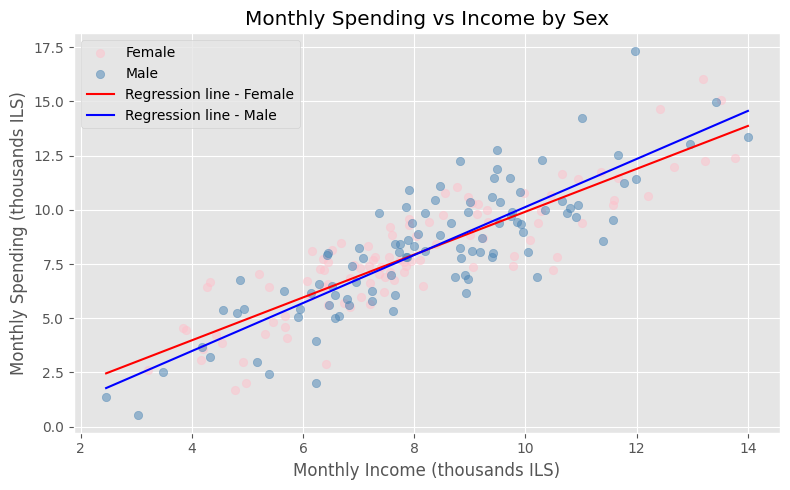

In [ ]:
df_male = df[df['sex'] == 1]
df_female = df[df['sex'] == 0]

plt.figure(figsize=(8, 5))

plt.scatter(df_female['income'], df_female['spend'], color='pink', alpha=0.5, label='Female')
plt.scatter(df_male['income'], df_male['spend'], color='steelblue', alpha=0.5, label='Male')

x_range = np.linspace(df['income'].min(), df['income'].max(), 100)

y_female = model.params['Intercept'] + model.params['income'] * x_range
y_male = (model.params['Intercept'] + model.params['sex']) + (model.params['income'] + model.params['income:sex']) * x_range

plt.plot(x_range, y_female, color='red', label='Regression line - Female')
plt.plot(x_range, y_male, color='blue', label='Regression line - Male')

plt.xlabel('Monthly Income (thousands ILS)')
plt.ylabel('Monthly Spending (thousands ILS)')
plt.title('Monthly Spending vs Income by Sex')
plt.legend()
plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>מהגרף ניתן לראות כי שני קווי הרגרסיה כמעט מקבילים — השיפועים דומים מאוד לגברים ולנשים, בעקביות עם המסקנה מסעיף א שאיבר האינטראקציה אינו מובהק. כמו כן, החותכים קרובים זה לזה, כלומר לא נמצא הבדל משמעותי בין המינים בהוצאות החודשיות בהינתן רמת הכנסה זהה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 2</p>

<p> בצע בדיקה סטטיסטית כדי לבדוק האם הקשר בין הכנסה להוצאות שונה לפי מין. נסח את ההשערה הנבדקת. הצג את סטטיסטיקת הבדיקה. דון בתוצאות.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>הקשר בין הכנסה להוצאות שונה לפי מין אם ואחד בלבד אם השיפוע שונה בין גברים לנשים, כלומר אם איבר האינטראקציה מובהק. השערות המבחן:</p>

$$H_0: \beta_3 = 0$$

$$H_1: \beta_3 \neq 0$$

<p>תחת $H_0$, סטטיסטי המבחן מתפלג לפי התפלגות $t$ של סטודנט:</p>

$$t_s = \frac{\hat{\beta}_3}{\widehat{SD}(\hat{\beta}_3)} \sim_{H_0} t(n - p)$$

</div>

In [ ]:
t_stat = model.tvalues['income:sex']
p_val = model.pvalues['income:sex']
df_resid = int(model.df_resid)

alpha = 0.05
t_crit = stats.t.ppf(1 - alpha/2, df_resid)

print(f"t-statistic: {t_stat:.4f}")
print(f"t-critical (α=0.05, two-tailed): ±{t_crit:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"df: {df_resid}")
print(f"Reject H₀? {abs(t_stat) > t_crit}")

t-statistic: 1.2914
t-critical (α=0.05, two-tailed): ±1.9721
p-value: 0.1981
df: 196
Reject H₀? False


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>מתקבל $t_s = 1.291$ עם $df = 196$, $t_c = 1.972$ ו-$p\text{-value} = 0.198 > \alpha = 0.05$. מאחר ש-$|t_s| < t_c$, לא דוחים את $H_0$ — אין עדות סטטיסטית לכך שהקשר בין הכנסה להוצאות שונה בין גברים לנשים.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 3</p>

<p>השתמש בגישה הטובה ביותר הגלובלית עם קריטריון $\bar{R}^2$ כדי לבחור את המודל הטוב ביותר. סכם את התוצאות.</p>

</div>

In [ ]:
features = ['income', 'sex', 'income:sex']

results = []

for k in range(1, len(features) + 1):
    for combo in combinations(features, k):
        formula = 'spend ~ ' + ' + '.join(combo)
        model_sub = smf.ols(formula, data=df).fit()
        results.append({'features': combo,
                        'formula': formula,
                        'adj_r2': model_sub.rsquared_adj})

results_df = pd.DataFrame(results).sort_values('adj_r2', ascending=False)
print(results_df.to_string(index=False))

                 features                           formula  adj_r2
                (income,)                    spend ~ income  0.7233
(income, sex, income:sex) spend ~ income + sex + income:sex  0.7228
     (income, income:sex)       spend ~ income + income:sex  0.7220
            (income, sex)              spend ~ income + sex  0.7219
        (sex, income:sex)          spend ~ sex + income:sex  0.3770
            (income:sex,)                spend ~ income:sex  0.0744
                   (sex,)                       spend ~ sex -0.0007


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>נבדקו כל תת-הקבוצות האפשריות של המשתנים. המודל הטוב ביותר לפי $\bar{R}^2$ הוא:</p>

$$\hat{Y}_i = \beta_0 + \beta_1 X_i + \epsilon_i$$

<p>עם $\bar{R}^2 = 0.723$. המסקנה היא שהוספת משתנה המין ואיבר האינטראקציה אינה משפרת את המודל — ההכנסה לבדה מספיקה לחיזוי ההוצאות.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 4</p>

<p>השתמש באלגוריתמים Stepwise, Backwards ו-Forward עם קריטריון AIC כדי לבחור את המודל הטוב ביותר. סכם את התוצאות. עבור כל שיטה, הצג את המודל ההתחלתי והסופי. האם המודל הטוב ביותר שונה כפונקציה של שיטת הבחירה?</p>

<hr>

</div>

In [ ]:
def stepwise_selection(data, response, candidates, direction='both'):
    def get_aic(formula):
        return smf.ols(formula, data=data).fit().aic

    if direction == 'backward':
        selected = candidates.copy()
        remaining = []
    else:
        selected = []
        remaining = candidates.copy()

    current_aic = get_aic(f'{response} ~ ' + (' + '.join(selected) if selected else '1'))

    while True:
        changed = False

        if direction in ('forward', 'both'):
            for f in remaining:
                formula = f'{response} ~ ' + ' + '.join(selected + [f])
                aic = get_aic(formula)
                if aic < current_aic:
                    selected.append(f)
                    remaining.remove(f)
                    current_aic = aic
                    changed = True
                    break

        if direction in ('backward', 'both') and len(selected) > 0:
            for f in selected:
                others = [x for x in selected if x != f]
                formula = f'{response} ~ ' + (' + '.join(others) if others else '1')
                aic = get_aic(formula)
                if aic < current_aic:
                    selected.remove(f)
                    remaining.append(f)
                    current_aic = aic
                    changed = True
                    break

        if not changed:
            break

    return selected, current_aic

In [ ]:
all_features = ['income', 'sex', 'income:sex']

forward_sel,  forward_aic  = stepwise_selection(df, 'spend', all_features, direction='forward')
backward_sel, backward_aic = stepwise_selection(df, 'spend', all_features, direction='backward')
stepwise_sel, stepwise_aic = stepwise_selection(df, 'spend', all_features, direction='both')

print(f"Forward  — initial: intercept only, final: {forward_sel},  AIC: {forward_aic:.2f}")
print(f"Backward — initial: {all_features}, final: {backward_sel},  AIC: {backward_aic:.2f}")
print(f"Stepwise — initial: intercept only, final: {stepwise_sel}, AIC: {stepwise_aic:.2f}")

Forward  — initial: intercept only, final: ['income'],  AIC: 731.36
Backward — initial: ['income', 'sex', 'income:sex'], final: ['income'],  AIC: 731.36
Stepwise — initial: intercept only, final: ['income'], AIC: 731.36


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שלוש השיטות מובילות לאותו מודל סופי:</p>

$$\hat{Y}_i = \beta_0 + \beta_1 X_i + \epsilon_i$$

<p>אלגוריתם Forward התחיל ממודל ריק והוסיף את income בלבד. אלגוריתם Backward התחיל מהמודל המלא והוריד שלב-שלב את sex ואת איבר האינטראקציה. אלגוריתם Stepwise התחיל ממודל ריק והגיע לאותה תוצאה. המודל הטוב ביותר אינו תלוי בשיטת הבחירה — בכולן ההכנסה לבדה מסבירה את ההוצאות בצורה האופטימלית לפי קריטריון אקאיקה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q1 שאלה 5</p>

<p>השתמש באלגוריתם Relaxed LASSO (עם CV פי 10 לבחירת פרמטר הכוונון) כדי למצוא את המודל הטוב ביותר. הצג את המודל הסופי. דווח והשווה את תוצאותיך למודל הרגרסיה השלבית הטוב ביותר של קריטריון AIC.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אלגוריתם Relaxed LASSO פועל בשני שלבים:</p>

<ol type="a">
<li>שלב הבחירה — מריצים LASSO רגיל עם פרמטר רגולריזציה $\lambda$ שנבחר באמצעות 10-fold CV. שלב זה מזהה אילו משתנים נכנסים למודל (אלה שמקדמיהם אינם אפס).</li>
<li>שלב ההרפיה — מריצים OLS רגיל רק על המשתנים שנבחרו בשלב 1, ללא רגולריזציה. כך מקבלים אומדנים לא-מוטים למקדמים שנבחרו.</li>
</ol>

<p>היתרון: LASSO רגיל מצמצם את המקדמים לכיוון אפס ולכן יוצר הטיה. ב-Relaxed LASSO מנצלים את LASSO לבחירת משתנים בלבד, ואז משתמשים ב-OLS לאמידה ללא הטיה.</p>

<p>הערה חשובה: LASSO רגיש לסקאלת המשתנים, מאחר שהקנס $\lambda \sum |\beta_j|$ מיושם באופן אחיד על כל המקדמים. משתנה עם סקאלה גדולה יקבל מקדם קטן באופן יחסי, ולכן ייוצר עיוות בבחירת המשתנים. לכן לפני הרצת LASSO מבצעים סטנדרטיזציה של המשתנים — נורמליזציה לממוצע 0 וסטיית תקן 1.</p>

</div>

In [ ]:
df['income_sex'] = df['income'] * df['sex']

X = df[['income', 'sex', 'income_sex']].values
y = df['spend'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=10, random_state=42).fit(X_scaled, y)
best_lambda = lasso_cv.alpha_
lasso_coefs = lasso_cv.coef_

feature_names = ['income', 'sex', 'income:sex']
selected = [name for name, c in zip(feature_names, lasso_coefs) if c != 0]

print(f"Best lambda (CV): {best_lambda:.4f}")
print(f"LASSO coefficients (standardized): {dict(zip(feature_names, lasso_coefs.round(4)))}")
print(f"Selected variables: {selected}")

Best lambda (CV): 0.0849
LASSO coefficients (standardized): {'income': np.float64(2.334), 'sex': np.float64(0.0), 'income:sex': np.float64(0.0)}
Selected variables: ['income']


In [ ]:
if selected:
    formula = 'spend ~ ' + ' + '.join(selected)
else:
    formula = 'spend ~ 1'

relaxed_model = smf.ols(formula, data=df).fit()
print(relaxed_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  spend   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.723
Method:                 Least Squares   F-statistic:                     521.1
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.34e-57
Time:                        08:34:12   Log-Likelihood:                -363.68
No. Observations:                 200   AIC:                             731.4
Df Residuals:                     198   BIC:                             738.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4139      0.385     -1.076      0.2

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>תוצאות אלגוריתם Relaxed LASSO:</p>

<ul>
<li>פרמטר הכוונון שנבחר ב-CV: $\lambda = 0.0849$.</li>
<li>בשלב הבחירה, LASSO השאיר משתנה אחד בלבד — income. המקדמים של sex ושל איבר האינטראקציה אופסו.</li>
<li>בשלב ההרפיה, OLS על המשתנה שנבחר נתן $\bar{R}^2 = 0.723$ וערך AIC של 731.4.</li>
</ul>

<p>השוואה למודל Stepwise AIC:</p>

<ul>
<li>Stepwise AIC בחר רק את income, עם ערך AIC של 731.36.</li>
<li>Relaxed LASSO הגיע לאותו מודל בדיוק, עם ערך AIC של 731.4.</li>
<li>שתי השיטות מסכימות שההכנסה היא המשתנה המסביר היחיד הדרוש לחיזוי ההוצאות, וששאר המשתנים אינם תורמים מובהקית, בעקביות עם תוצאות סעיפים 1, 2, 3 ו-4.</li>
</ul>

<p>שתי השיטות הביאו לאותו מודל סופי — המודל הפשוט עם income בלבד. זוהי תוצאה מבוקשת, מאחר שהיא מאשרת ששיטות שונות לבחירת משתנים מצביעות על אותו מבנה אופטימלי. בכך, לא נוצרת בעיה של הפרת עקרון ההיררכיה, ולא נשאר משתנה מיותר במודל.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2</p>

<p>קראו את קובץ psych_data.txt. הוא מכיל נתונים על 999 סטודנטים מחיפה, תל אביב וירושלים שניגשו לבחינה הפסיכומטרית. המשתנים הם:</p>

<ul>
<li>psych — ציון הבחינה (ערך שלם בין 200 ל-800).</li>
<li>city — העיר בה ניגש הסטודנט לבחינה: חיפה, תל אביב או ירושלים.</li>
<li>income — ההכנסה החודשית המדווחת של משפחת הסטודנט באלפי ש"ח.</li>
<li>age — גיל הסטודנט בעת הבחינה.</li>
</ul>

<p>המשימה שלנו היא למצוא את המודל הטוב ביותר האפשרי שחוזה את ציוני הבחינה הפסיכומטרית באמצעות הכנסה משפחתית, עיר וגיל.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2 שאלה 1</p>

<p>קראו את הקובץ וספקו סיכום תמציתי של הנתונים. הן חזותי והן מספרי.</p>

<hr>

</div>

In [ ]:
psych_df = pd.read_csv(os.path.join(path, 'psych_data.txt'), sep=r'\s+')
psych_df.head()

,psych,income,city,age
0,521,8.2600,Haifa,26
1,568,18.1200,Haifa,35
2,672,17.7800,Haifa,30
3,587,13.0300,Haifa,25
4,408,4.9600,Haifa,27


In [ ]:
psych_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   psych   999 non-null    int64  
 1   income  999 non-null    float64
 2   city    999 non-null    object 
 3   age     999 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 31.3+ KB


In [ ]:
psych_df.describe()

,psych,income,age
count,999.0000,999.0000,999.0000
mean,542.9660,14.0537,29.9610
std,81.2454,5.7135,4.1405
min,291.0000,2.2000,18.0000
25%,488.0000,10.1100,27.0000
50%,540.0000,13.2200,30.0000
75%,597.0000,17.0900,33.0000
max,800.0000,44.8100,42.0000


In [ ]:
psych_df['city'].value_counts()

,count
city,
Haifa,333
TLV,333
Jerusalem,333


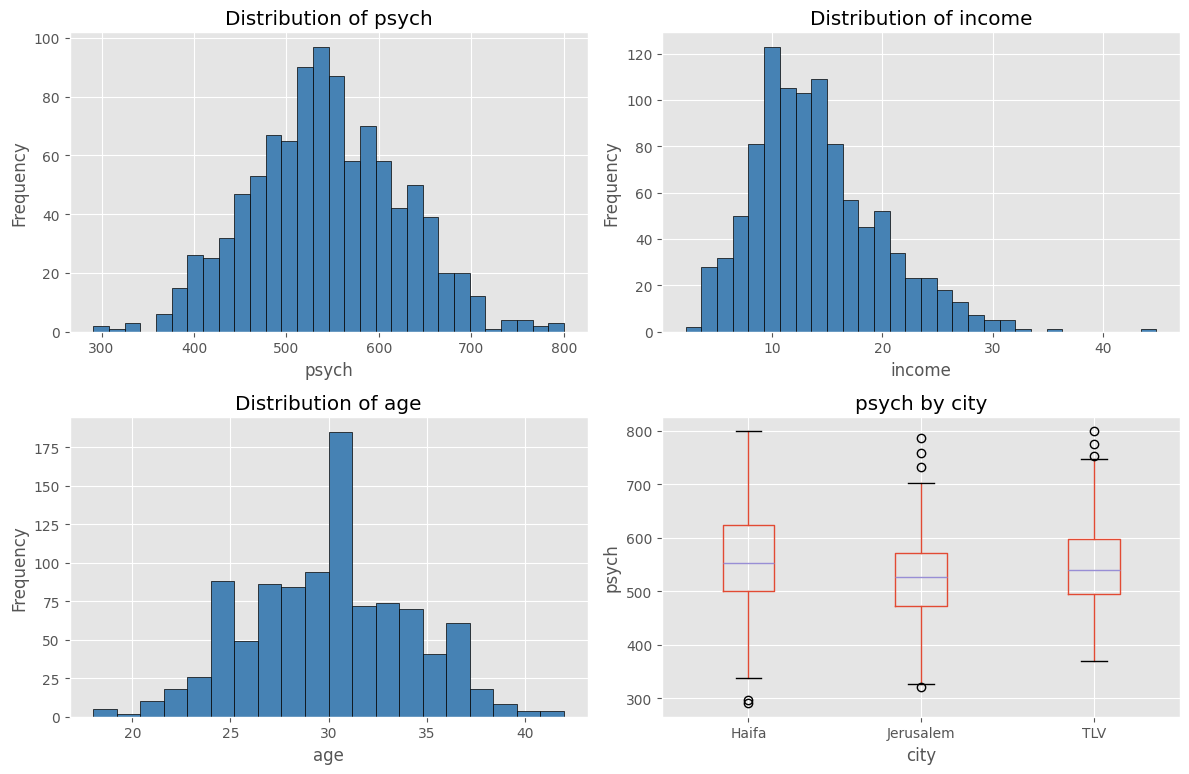

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(psych_df['psych'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('psych')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of psych')

axes[0, 1].hist(psych_df['income'], bins=30, color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('income')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of income')

axes[1, 0].hist(psych_df['age'], bins=20, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of age')

psych_df.boxplot(column='psych', by='city', ax=axes[1, 1])
axes[1, 1].set_xlabel('city')
axes[1, 1].set_ylabel('psych')
axes[1, 1].set_title('psych by city')
plt.suptitle('')

plt.tight_layout()
plt.show()

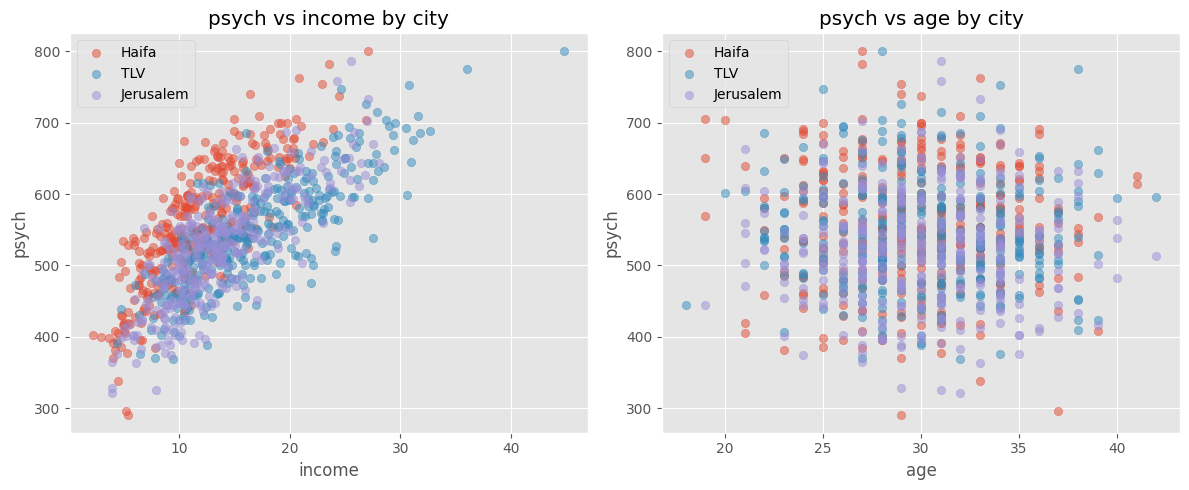

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for city in psych_df['city'].unique():
    sub = psych_df[psych_df['city'] == city]
    axes[0].scatter(sub['income'], sub['psych'], alpha=0.5, label=city)
    axes[1].scatter(sub['age'], sub['psych'], alpha=0.5, label=city)

axes[0].set_xlabel('income')
axes[0].set_ylabel('psych')
axes[0].set_title('psych vs income by city')
axes[0].legend()

axes[1].set_xlabel('age')
axes[1].set_ylabel('psych')
axes[1].set_title('psych vs age by city')
axes[1].legend()

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>הנתונים כוללים 999 תצפיות, מאוזנות בין שלוש הערים — 333 סטודנטים בכל אחת מחיפה, תל אביב וירושלים. אין ערכים חסרים.</p>

<p>סיכום מספרי:</p>

<ul>
<li>psych — ממוצע 543, סטיית תקן 81, טווח 291 עד 800.</li>
<li>income — ממוצע 14.05 אלפי ש"ח, סטיית תקן 5.71, טווח 2.2 עד 44.8. ההתפלגות אסימטרית ימינה.</li>
<li>age — ממוצע 30, סטיית תקן 4.14, טווח 18 עד 42. ההתפלגות מרוכזת סביב גיל 30.</li>
</ul>

<p>סיכום חזותי:</p>

<ul>
<li>ההתפלגות של psych קרובה לנורמלית, ההתפלגות של income אסימטרית ימינה, וההתפלגות של age קרובה לנורמלית עם ריכוז ברור סביב גיל 30.</li>
<li>בהשוואת psych בין הערים נראים הבדלים קטנים בלבד — חיפה עם חציון מעט גבוה יותר, אך החפיפה בין הקבוצות גדולה.</li>
<li>בגרף הפיזור של psych מול income נראה קשר חיובי לא-ליניארי, בעל צורה קעורה — הציון עולה במהירות בהכנסות נמוכות ומתמתן בהכנסות גבוהות. תופעה זו תהיה רלוונטית לסעיף 3 שבו נשקול טרנספורמציות לא-ליניאריות של income.</li>
<li>בגרף הפיזור של psych מול age לא נראה קשר ברור — נראה ענן פיזור ללא מגמה.</li>
</ul>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2 שאלה 2</p>

<p>השתמש רק במשתנים הזמינים, ללא אינטראקציות, כדי למצוא את המודל הטוב ביותר באמצעות גישת כל תת-הקבוצות (הטוב ביותר הגלובלי) עם קריטריון $\bar{R}^2$. סכם את התוצאות. הצג במפורש את המודל הטוב ביותר.</p>


</div>

In [ ]:
features = ['income', 'C(city)', 'age']

results = []
for k in range(0, len(features) + 1):
    for combo in combinations(features, k):
        if len(combo) == 0:
            formula = 'psych ~ 1'
        else:
            formula = 'psych ~ ' + ' + '.join(combo)
        m = smf.ols(formula, data=psych_df).fit()
        results.append({
            'features': combo if combo else ('intercept only',),
            'formula': formula,
            'adj_r2': m.rsquared_adj
        })

results_df = pd.DataFrame(results).sort_values('adj_r2', ascending=False)
print(results_df.to_string(index=False))

              features                        formula  adj_r2
     (income, C(city))       psych ~ income + C(city)  0.6430
(income, C(city), age) psych ~ income + C(city) + age  0.6426
             (income,)                 psych ~ income  0.5191
         (income, age)           psych ~ income + age  0.5189
            (C(city),)                psych ~ C(city)  0.0263
        (C(city), age)          psych ~ C(city) + age  0.0258
     (intercept only,)                      psych ~ 1 -0.0000
                (age,)                    psych ~ age -0.0005


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>נבדקו כל תת-הקבוצות האפשריות של המשתנים הזמינים — סך הכל 8 מודלים. המודל הטוב ביותר לפי $\bar{R}^2$ הוא:</p>

$$\hat{Y}_i = \beta_0 + \beta_1 \cdot \text{income}_i + \beta_2 \cdot D_{\text{Jerusalem},i} + \beta_3 \cdot D_{\text{TLV},i} + \epsilon_i$$

<p>עם $\bar{R}^2 = 0.6430$. המודל מסביר כ-64% מהשונות בציוני הפסיכומטרי.</p>

<p>תובנות מהטבלה:</p>

<ul>
<li>income הוא המשתנה הדומיננטי — לבדו הוא נותן $\bar{R}^2 = 0.519$, ועם הוספת city קופץ ל-0.643.</li>
<li>age כמעט לא תורם — הוספתו למודל המנצח מורידה את $\bar{R}^2$ מ-0.643 ל-0.6426, ירידה זניחה. זה עקבי עם הניתוח החזותי בסעיף 1 שבו לא נראה קשר ברור בין age ל-psych.</li>
<li>city לבדה מסבירה כ-2.6% בלבד מהשונות, מה שמראה שעיקר ההבדל בין הערים נובע מהכנסה ולא מהעיר עצמה.</li>
</ul>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2 שאלה 3</p>

<p>הוסף את כל האינטראקציות הזוגיות בין עיר להכנסה, וקח בחשבון פונקציות לא-לינאריות של הכנסה. אילו טרנספורמציות לא-לינאריות סבירות יותר — קעורות או קמורות? בהתאם לתשובה, הוסף טרנספורמציות אלו כמשתנים חדשים למערך הנתונים.</p>

<hr>

</div>

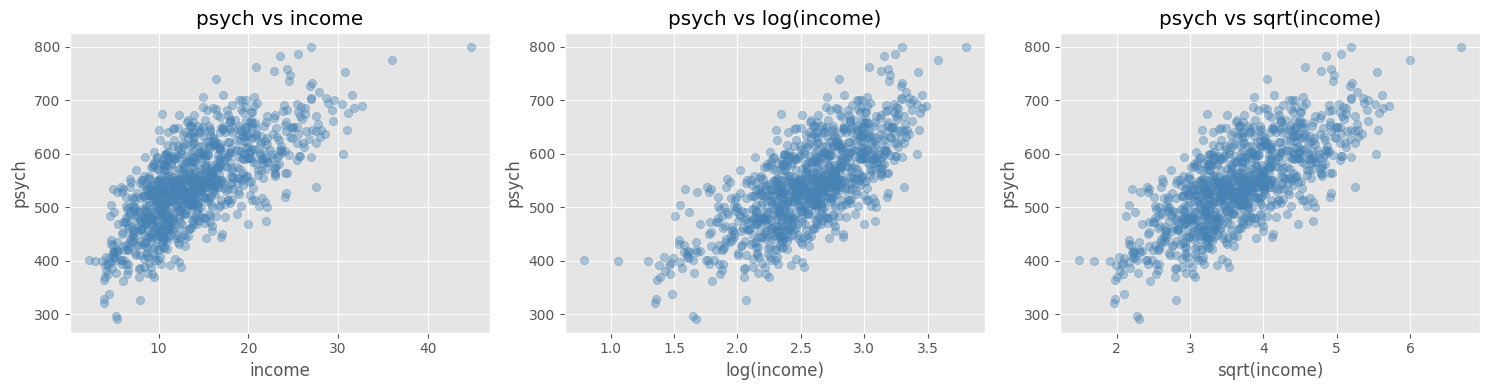

In [ ]:
psych_df['log_income'] = np.log(psych_df['income'])
psych_df['sqrt_income'] = np.sqrt(psych_df['income'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(psych_df['income'], psych_df['psych'], alpha=0.4, color='steelblue')
axes[0].set_xlabel('income')
axes[0].set_ylabel('psych')
axes[0].set_title('psych vs income')

axes[1].scatter(psych_df['log_income'], psych_df['psych'], alpha=0.4, color='steelblue')
axes[1].set_xlabel('log(income)')
axes[1].set_ylabel('psych')
axes[1].set_title('psych vs log(income)')

axes[2].scatter(psych_df['sqrt_income'], psych_df['psych'], alpha=0.4, color='steelblue')
axes[2].set_xlabel('sqrt(income)')
axes[2].set_ylabel('psych')
axes[2].set_title('psych vs sqrt(income)')

plt.tight_layout()
plt.show()

In [ ]:
print("Correlation with psych:")
print(f"  income:       {psych_df['psych'].corr(psych_df['income']):.4f}")
print(f"  log(income):  {psych_df['psych'].corr(psych_df['log_income']):.4f}")
print(f"  sqrt(income): {psych_df['psych'].corr(psych_df['sqrt_income']):.4f}")

Correlation with psych:
  income:       0.7208
  log(income):  0.7298
  sqrt(income): 0.7325


In [ ]:
if 'city_x_income' in psych_df.columns:
    psych_df = psych_df.drop(columns=['city_x_income'])

print("Variables added to the dataset:")
print(f"  - log_income (concave transformation)")
print(f"  - sqrt_income (concave transformation)")
print(f"  - city x income interactions will be handled via the formula C(city):income in later sections")

print("\nDataframe columns:")
print(psych_df.columns.tolist())
print("\nFirst few rows:")
print(psych_df.head())

Variables added to the dataset:
  - log_income (concave transformation)
  - sqrt_income (concave transformation)
  - city x income interactions will be handled via the formula C(city):income in later sections

Dataframe columns:
['psych', 'income', 'city', 'age', 'log_income', 'sqrt_income']

First few rows:
   psych  income   city  age  log_income  sqrt_income
0    521  8.2600  Haifa   26      2.1114       2.8740
1    568 18.1200  Haifa   35      2.8970       4.2568
2    672 17.7800  Haifa   30      2.8781       4.2166
3    587 13.0300  Haifa   25      2.5673       3.6097
4    408  4.9600  Haifa   27      1.6014       2.2271


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>בסעיף 1 ראינו בגרף הפיזור של psych מול income קשר חיובי לא-ליניארי בעל צורה קעורה — הציון עולה במהירות בהכנסות נמוכות ומתמתן בהכנסות גבוהות. מבחינה אינטואיטיבית, זוהי "תשואה פוחתת": משפחה שמגדילה את הכנסתה מ-5 ל-10 אלף ש"ח יכולה לממן הרבה יותר חוגי הכנה והעשרה, בעוד שמשפחה שמגדילה את הכנסתה מ-30 ל-35 אלף תוסיף שיעור פרטי נוסף שכבר לא משנה הרבה.</p>

<p>לכן הטרנספורמציות הסבירות הן קעורות — פונקציות עם נגזרת שנייה שלילית. דוגמאות מוכרות הן $\log(x)$ ו-$\sqrt{x}$.</p>

<p>נוסיף שני משתנים חדשים לדאטה:</p>

<ul>
<li>log_income — לוגריתם טבעי של ההכנסה.</li>
<li>sqrt_income — שורש ריבועי של ההכנסה.</li>
</ul>

<p>השוואת המתאמים עם psych:</p>

<ul>
<li>income: $r = 0.7208$</li>
<li>log(income): $r = 0.7298$</li>
<li>sqrt(income): $r = 0.7325$</li>
</ul>

<p>שתי הטרנספורמציות הקעורות מניבות מתאם גבוה יותר מאשר income המקורי, מה שמאשר את הצורך בטרנספורמציה לא-ליניארית. sqrt(income) נותן את המתאם הגבוה ביותר.</p>

<p>בנוסף, השאלה דורשת אינטראקציות זוגיות בין city ל-income. מאחר שבחרנו להחליף את income בטרנספורמציה הקעורה sqrt_income (שמספקת מתאם גבוה יותר עם psych ועקבית עם צורת הקשר שזיהינו), האינטראקציות יוכנסו דרך C(city):sqrt_income. שילוב של C(city):income ו-C(city):sqrt_income באותו מודל אינו אפשרי בגלל מולטיקוליניאריות חריפה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2 שאלה 4</p>

<p>בחר את המודל הטוב ביותר באמצעות (1) Stepwise AIC ו-(2) Leave-One-Out CV (MSE). השווה את התוצאות. בצע אבחון מודל של המודל הסופי.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>נבחר את המודל הטוב ביותר באמצעות שתי שיטות עצמאיות ונשווה את התוצאות:</p>

<ol type="a">
<li>Stepwise AIC — אלגוריתם שלבי שמוסיף ומסיר משתנים בהתאם לקריטריון AIC.</li>
<li>Leave-One-Out CV — מסירים תצפית אחת בכל פעם, מאמנים את המודל על השאר, וחוזים את התצפית שהוסרה. ה-MSE הוא הממוצע של ריבועי השגיאות. המודל עם ה-MSE הנמוך ביותר הוא הזוכה.</li>
</ol>

<p>המשתנים המועמדים: sqrt_income (טרנספורמציה קעורה מסעיף 3), C(city), age, ואיבר האינטראקציה C(city):sqrt_income. בחרנו ב-sqrt_income מבין שתי הטרנספורמציות הקעורות מאחר שהוא נתן את המתאם הגבוה ביותר עם psych. לא ניתן לכלול את income, log_income ו-sqrt_income יחד באותו מודל בגלל מולטיקוליניאריות.</p>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שיטה 1 — Stepwise AIC</p>

</div>

In [ ]:
def stepwise_selection_hierarchical(data, response, candidates, direction='both', model_type='ols'):
    fit_func = smf.logit if model_type == 'logit' else smf.ols

    def get_aic(formula):
        return fit_func(formula, data=data).fit(disp=False).aic

    def get_required_mains(feature):
        if ':' not in feature:
            return []
        return [p for p in feature.split(':') if p in candidates]

    def is_valid(selected):
        for f in selected:
            for main in get_required_mains(f):
                if main not in selected:
                    return False
        return True

    if direction == 'backward':
        selected = candidates.copy()
        remaining = []
    else:
        selected = []
        remaining = candidates.copy()

    current_aic = get_aic(f'{response} ~ ' + (' + '.join(selected) if selected else '1'))

    while True:
        changed = False

        if direction in ('forward', 'both'):
            for f in remaining:
                trial = selected + [f]
                if not is_valid(trial):
                    continue
                aic = get_aic(f'{response} ~ ' + ' + '.join(trial))
                if aic < current_aic:
                    selected.append(f)
                    remaining.remove(f)
                    current_aic = aic
                    changed = True
                    break

        if direction in ('backward', 'both') and len(selected) > 0:
            for f in selected:
                trial = [x for x in selected if x != f]
                if not is_valid(trial):
                    continue
                aic = get_aic(f'{response} ~ ' + (' + '.join(trial) if trial else '1'))
                if aic < current_aic:
                    selected.remove(f)
                    remaining.append(f)
                    current_aic = aic
                    changed = True
                    break

        if not changed:
            break

    return selected, current_aic

In [ ]:
all_features = ['sqrt_income', 'C(city)', 'age', 'C(city):sqrt_income']

stepwise_sel, stepwise_aic = stepwise_selection_hierarchical(psych_df, 'psych', all_features, direction='both')

print(f"Stepwise AIC — final features: {stepwise_sel}")
print(f"Stepwise AIC — final AIC: {stepwise_aic:.2f}")

Stepwise AIC — final features: ['sqrt_income', 'C(city)', 'C(city):sqrt_income']
Stepwise AIC — final AIC: 10510.64


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שיטה 2 — Leave-One-Out CV</p>

</div>

In [ ]:
def is_hierarchical_combo(combo, candidates):
    for f in combo:
        if ':' in f:
            parts = f.split(':')
            for p in parts:
                if p in candidates and p not in combo:
                    return False
    return True

In [ ]:
all_features = ['sqrt_income', 'C(city)', 'age', 'C(city):sqrt_income']

loo_results = []
for k in range(0, len(all_features) + 1):
    for combo in combinations(all_features, k):
        if not is_hierarchical_combo(combo, all_features):
            continue

        if len(combo) == 0:
            formula = 'psych ~ 1'
        else:
            formula = 'psych ~ ' + ' + '.join(combo)

        y_true = psych_df['psych'].values
        y_pred = np.zeros(len(psych_df))

        for i in range(len(psych_df)):
            train = psych_df.drop(psych_df.index[i])
            test = psych_df.iloc[[i]]
            m = smf.ols(formula, data=train).fit()
            y_pred[i] = m.predict(test).values[0]

        mse = np.mean((y_true - y_pred) ** 2)
        loo_results.append({'formula': formula, 'features': combo, 'LOO_MSE': mse})

loo_df = pd.DataFrame(loo_results).sort_values('LOO_MSE')
print(loo_df.to_string(index=False))

                                                  formula                                         features   LOO_MSE
      psych ~ sqrt_income + C(city) + C(city):sqrt_income      (sqrt_income, C(city), C(city):sqrt_income) 2171.4062
psych ~ sqrt_income + C(city) + age + C(city):sqrt_income (sqrt_income, C(city), age, C(city):sqrt_income) 2175.4915
                            psych ~ sqrt_income + C(city)                           (sqrt_income, C(city)) 2205.7529
                      psych ~ sqrt_income + C(city) + age                      (sqrt_income, C(city), age) 2209.9648
                                      psych ~ sqrt_income                                   (sqrt_income,) 3067.3697
                                psych ~ sqrt_income + age                               (sqrt_income, age) 3070.9995
                                          psych ~ C(city)                                       (C(city),) 6446.3620
                                    psych ~ C(city) + age       

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אבחון המודל הסופי</p>

</div>

In [ ]:
final_formula = 'psych ~ ' + ' + '.join(stepwise_sel)
final_model = smf.ols(final_formula, data=psych_df).fit()
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     411.7
Date:                Mon, 18 May 2026   Prob (F-statistic):          3.87e-239
Time:                        08:35:52   Log-Likelihood:                -5249.3
No. Observations:                 999   AIC:                         1.051e+04
Df Residuals:                     993   BIC:                         1.054e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
Intercep

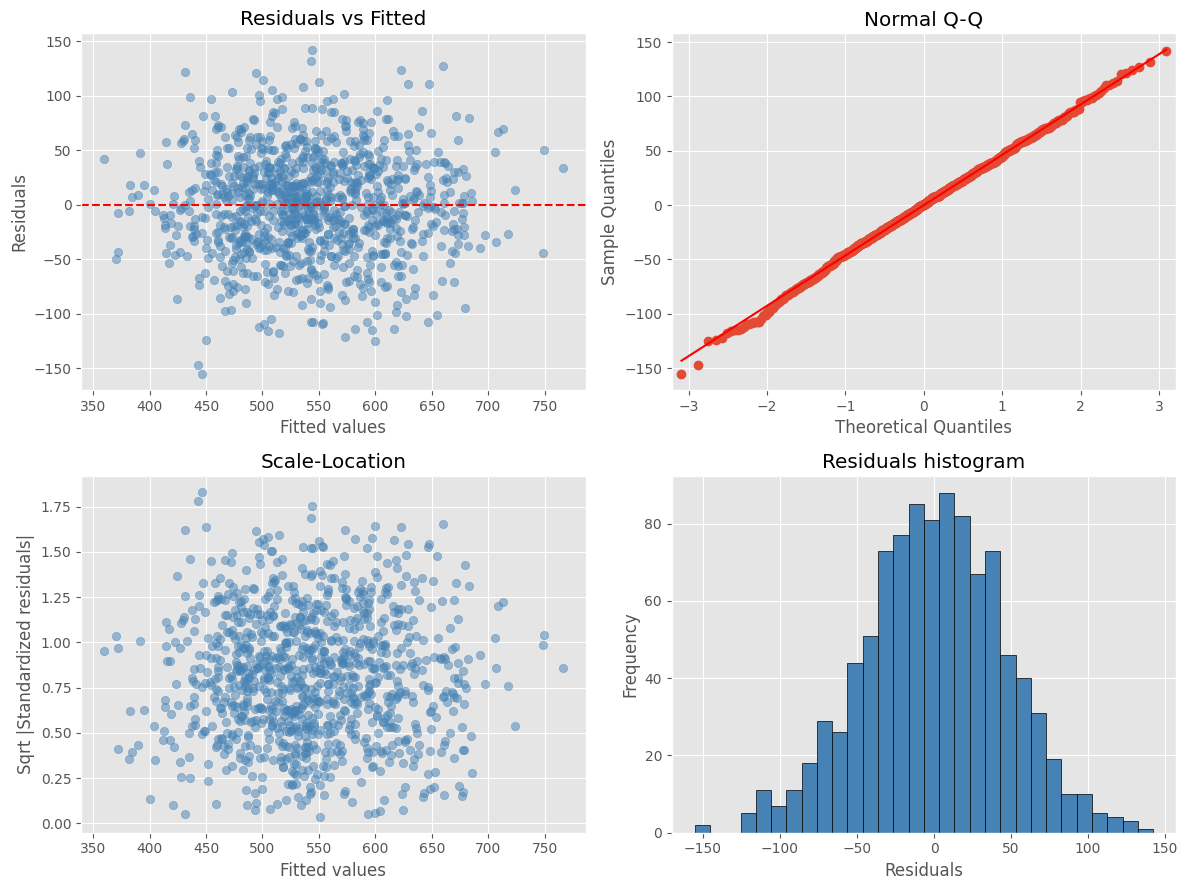

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(final_model.fittedvalues, final_model.resid, alpha=0.5, color='steelblue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Fitted values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

sm.qqplot(final_model.resid, line='s', ax=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q')

standardized = (final_model.resid - final_model.resid.mean()) / final_model.resid.std()
axes[1, 0].scatter(final_model.fittedvalues, np.sqrt(np.abs(standardized)), alpha=0.5, color='steelblue')
axes[1, 0].set_xlabel('Fitted values')
axes[1, 0].set_ylabel('Sqrt |Standardized residuals|')
axes[1, 0].set_title('Scale-Location')

axes[1, 1].hist(final_model.resid, bins=30, color='steelblue', edgecolor='black')
axes[1, 1].set_xlabel('Residuals')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Residuals histogram')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>השוואת השיטות:</p>

<ul>
<li>Stepwise AIC בחר: sqrt_income + C(city) + C(city):sqrt_income, AIC = 10510.64.</li>
<li>LOO-CV בחר באותו מודל בדיוק, LOO-MSE = 2171.41.</li>
</ul>

<p>שתי השיטות מסכימות על אותו מודל. המודל עומד בעקרון ההיררכיה.</p>

<p>מאפייני המודל הסופי:</p>

<ul>
<li>$R^2 = 0.675$ — המודל מסביר כ-67.5% מהשונות.</li>
<li>$F = 411.7$, $p < 10^{-238}$ — מובהק מאוד.</li>
<li>sqrt_income ואיברי האינטראקציה מובהקים. האפקטים העיקריים של C(city) נכללים בגלל ההיררכיה.</li>
</ul>

<p>פרשנות: הקשר בין הכנסה לציון קעור (תשואה פוחתת), והשיפוע משתנה בין הערים.</p>

<p>אבחון המודל:</p>

<ul>
<li>Residuals vs Fitted — פיזור אקראי סביב 0, ליניאריות תקינה.</li>
<li>Q-Q plot — הנקודות על הקו, נורמליות תקינה.</li>
<li>Scale-Location — פיזור אחיד, שוויון שונויות מתקיים.</li>
<li>היסטוגרמה — צורת פעמון סימטרית.</li>
</ul>

<p>מסקנה: כל ההנחות של רגרסיה ליניארית מתקיימות.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q2 שאלה 5</p>

<p>השתמש באלגוריתם Relaxed LASSO (עם CV פי 10 לבחירת פרמטר הכוונון) כדי למצוא את המודל הטוב ביותר. דווח והשווה את תוצאותיך למודל הרגרסיה השלבית הטוב ביותר של קריטריון AIC.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>אלגוריתם Relaxed LASSO פועל בשני שלבים:</p>

<ol type="a">
<li>שלב הבחירה — מריצים LASSO עם פרמטר רגולריזציה $\lambda$ שנבחר באמצעות 10-fold CV. שלב זה מזהה אילו משתנים נכנסים למודל.</li>
<li>שלב ההרפיה — מריצים OLS רגיל רק על המשתנים שנבחרו, ללא רגולריזציה. כך מקבלים אומדנים לא-מוטים.</li>
</ol>

<p>בדומה לסעיף 1.5, נבצע סטנדרטיזציה של המשתנים לפני LASSO כדי שהקנס יחול באופן הוגן על כל מקדם.</p>

<p>מבנה המועמדים: sqrt_income, age, ושני משתני dummy לעיר (Jerusalem, TLV עם Haifa כקבוצת הייחוס), בתוספת שני איברי אינטראקציה ביניהם.</p>

</div>

In [ ]:
psych_df['city_jerusalem'] = (psych_df['city'] == 'Jerusalem').astype(int)
psych_df['city_tlv'] = (psych_df['city'] == 'TLV').astype(int)
psych_df['sqrt_income_jerusalem'] = psych_df['sqrt_income'] * psych_df['city_jerusalem']
psych_df['sqrt_income_tlv'] = psych_df['sqrt_income'] * psych_df['city_tlv']

feature_cols = ['sqrt_income', 'age', 'city_jerusalem', 'city_tlv',
                'sqrt_income_jerusalem', 'sqrt_income_tlv']

X = psych_df[feature_cols].values
y = psych_df['psych'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lasso_cv = LassoCV(cv=10, random_state=42).fit(X_scaled, y)
best_lambda = lasso_cv.alpha_
lasso_coefs = lasso_cv.coef_

selected = [name for name, c in zip(feature_cols, lasso_coefs) if c != 0]

print(f"Best lambda (CV): {best_lambda:.4f}")
print(f"LASSO coefficients (standardized): {dict(zip(feature_cols, lasso_coefs.round(4)))}")
print(f"Selected variables: {selected}")

Best lambda (CV): 0.0843
LASSO coefficients (standardized): {'sqrt_income': np.float64(77.659), 'age': np.float64(-0.1928), 'city_jerusalem': np.float64(-10.8256), 'city_tlv': np.float64(0.0), 'sqrt_income_jerusalem': np.float64(-16.8603), 'sqrt_income_tlv': np.float64(-38.7426)}
Selected variables: ['sqrt_income', 'age', 'city_jerusalem', 'sqrt_income_jerusalem', 'sqrt_income_tlv']


In [ ]:
if selected:
    formula = 'psych ~ ' + ' + '.join(selected)
else:
    formula = 'psych ~ 1'

relaxed_model = smf.ols(formula, data=psych_df).fit()
print(relaxed_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  psych   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.673
Method:                 Least Squares   F-statistic:                     411.6
Date:                Mon, 18 May 2026   Prob (F-statistic):          4.26e-239
Time:                        08:35:52   Log-Likelihood:                -5249.4
No. Observations:                 999   AIC:                         1.051e+04
Df Residuals:                     993   BIC:                         1.054e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept               210.04

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>תוצאות Relaxed LASSO:</p>

<ul>
<li>$\lambda = 0.0843$.</li>
<li>LASSO השאיר 5 משתנים: sqrt_income, age, city_jerusalem, sqrt_income_jerusalem, sqrt_income_tlv. city_tlv אופס.</li>
<li>$\bar{R}^2 = 0.673$ — זהה ל-Stepwise AIC.</li>
</ul>

<p>השוואה ל-Stepwise AIC:</p>

<ul>
<li>Stepwise AIC: sqrt_income + C(city) + C(city):sqrt_income — מודל היררכי.</li>
<li>Relaxed LASSO כלל את age (לא מובהק, $p = 0.860$) ואת sqrt_income_tlv ללא city_tlv — מפר את עקרון ההיררכיה.</li>
<li>LASSO מטפל בכל מקדם בנפרד ואין לו מנגנון לכפות תלות בין מקדמים. גרסאות כמו Group LASSO ו-Hierarchical LASSO נועדו לפתור זאת.</li>
</ul>

<p>מסקנה: שני המודלים שווי-ערך בטיב ההתאמה לדאטה ($\bar{R}^2$ זהה), אך נבדלים מבנית. Stepwise AIC עדיף — היררכי, פרסימוני, וללא משתנים לא מובהקים.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q3</p>

<p>  </p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q3 שאלה 1</p>

<p>השתמש ב-Nonparametric Bootstrap כדי לחשב רווחי סמך ברמת 95% עבור כל מקדמי המודל. שרטט את התפלגויות ה-Bootstrap והשווה את התוצאות לרווחי הסמך האנליטיים מפלט המודל הסטנדרטי.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>המשתנה התלוי SURVIVED הוא בינארי, ולכן נשתמש ברגרסיה לוגיסטית. נסמן $p = P(\text{Survived} = 1)$. המודל המלא:</p>

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 \text{PCLASS} + \beta_2 \text{SEX} + \beta_3 \text{AGE} + \beta_4 (\text{SEX} \times \text{AGE})$$

<p>Nonparametric Bootstrap פועל באופן הבא:</p>

<ol type="a">
<li>דוגמים מהדאטה המקורי דגימה חדשה בגודל $n$ עם החזרה.</li>
<li>מתאימים את המודל על הדגימה ושומרים את המקדמים.</li>
<li>חוזרים על התהליך $B$ פעמים.</li>
<li>רווח הסמך ברמת 95% מתקבל מהאחוזונים 2.5% ו-97.5% של ההתפלגות הבוטסטראפית של כל מקדם.</li>
</ol>

<p>רווחי הסמך האנליטיים מהפלט הסטנדרטי מסתמכים על נורמליות אסימפטוטית של ה-MLE. ה-Bootstrap לא דורש הנחה זו, ולכן השוואה ביניהם מאששת או מערערת את תקפות ההנחות האסימפטוטיות.</p>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>המשתנה התלוי SURVIVED הוא בינארי, ולכן רגרסיה ליניארית רגילה אינה מתאימה. במקום זאת נשתמש ברגרסיה לוגיסטית — מודל שמתאים להסתברות שתצפית תקבל ערך 1.</p>

<p>נסמן $p = P(\text{Survived} = 1)$. המודל המלא:</p>

$$\ln\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 \text{PCLASS} + \beta_2 \text{SEX} + \beta_3 \text{AGE} + \beta_4 (\text{SEX} \times \text{AGE})$$

<p>אלגוריתם Nonparametric Bootstrap פועל בארבעה שלבים:</p>

<ol type="a">
<li>דוגמים מהדאטה המקורי דגימה חדשה בגודל $n$ עם החזרה.</li>
<li>מתאימים את המודל על הדגימה ושומרים את המקדמים.</li>
<li>חוזרים על התהליך $B$ פעמים (במקרה זה $B = 2000$).</li>
<li>רווח הסמך ברמת 95% מתקבל מהאחוזונים 2.5% ו-97.5% של ההתפלגות הבוטסטראפית של כל מקדם.</li>
</ol>

<p>רווחי הסמך האנליטיים מסתמכים על נורמליות אסימפטוטית של אומדן ה-MLE. ה-Bootstrap לעומת זאת אינו דורש הנחה זו, ולכן השוואה בין שתי הגישות בוחנת האם הנחת הנורמליות מתקיימת בפועל בנתונים שלנו.</p>

</div>

In [ ]:
titanic_df = pd.read_csv(os.path.join(path, 'titanic.csv'))

titanic_df = titanic_df.dropna(subset=['PCLASS', 'SEX', 'AGE', 'SURVIVED'])

print(f"Sample size: {len(titanic_df)}")
print(titanic_df.head())

Sample size: 679
   ID                                           NAME  PCLASS     AGE  SEX  \
0   1                   Allen, Miss Elisabeth Walton       1 29.0000    1   
1   2                    Allison, Miss Helen Loraine       1  2.0000    1   
2   3            Allison, Mr Hudson Joshua Creighton       1 30.0000    0   
3   4  Allison, Mrs Hudson JC (Bessie Waldo Daniels)       1 25.0000    1   
4   5                  Allison, Master Hudson Trevor       1  0.9200    0   

   SURVIVED  
0         1  
1         0  
2         0  
3         0  
4         1  


In [ ]:
formula = 'SURVIVED ~ PCLASS + SEX + AGE + SEX:AGE'
logit_model = smf.logit(formula, data=titanic_df).fit(disp=False)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:               SURVIVED   No. Observations:                  679
Model:                          Logit   Df Residuals:                      674
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.3650
Time:                        08:35:53   Log-Likelihood:                -295.29
converged:                       True   LL-Null:                       -465.06
Covariance Type:            nonrobust   LLR p-value:                 3.198e-72
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3674      0.517      6.516      0.000       2.354       4.380
PCLASS        -1.3143      0.154     -8.531      0.000      -1.616      -1.012
SEX            0.7242      0.473      1.531      0.1

In [ ]:
B = 2000
np.random.seed(42)

n = len(titanic_df)
boot_coefs = []

for b in range(B):
    sample_idx = np.random.choice(n, size=n, replace=True)
    boot_sample = titanic_df.iloc[sample_idx]
    try:
        boot_model = smf.logit(formula, data=boot_sample).fit(disp=False)
        boot_coefs.append(boot_model.params.values)
    except Exception:
        continue

boot_coefs = np.array(boot_coefs)
print(f"Successful bootstrap iterations: {len(boot_coefs)}")

Successful bootstrap iterations: 2000


In [ ]:
param_names = logit_model.params.index.tolist()

analytical_ci = logit_model.conf_int(alpha=0.05)
analytical_ci.columns = ['Analytical_Lower', 'Analytical_Upper']

boot_lower = np.percentile(boot_coefs, 2.5, axis=0)
boot_upper = np.percentile(boot_coefs, 97.5, axis=0)
boot_mean = np.mean(boot_coefs, axis=0)

comparison = pd.DataFrame({
    'Coefficient': logit_model.params.values.round(4),
    'Bootstrap_Mean': boot_mean.round(4),
    'Analytical_Lower': analytical_ci['Analytical_Lower'].values.round(4),
    'Analytical_Upper': analytical_ci['Analytical_Upper'].values.round(4),
    'Bootstrap_Lower': boot_lower.round(4),
    'Bootstrap_Upper': boot_upper.round(4),
}, index=param_names)

print(comparison)

           Coefficient  Bootstrap_Mean  Analytical_Lower  Analytical_Upper  \
Intercept       3.3674          3.3934            2.3545            4.3803   
PCLASS         -1.3143         -1.3271           -1.6162           -1.0123   
SEX             0.7242          0.7257           -0.2030            1.6513   
AGE            -0.0708         -0.0714           -0.0918           -0.0497   
SEX:AGE         0.0723          0.0736            0.0415            0.1031   

           Bootstrap_Lower  Bootstrap_Upper  
Intercept           2.4221           4.4512  
PCLASS             -1.6766          -1.0193  
SEX                -0.1851           1.6558  
AGE                -0.0932          -0.0510  
SEX:AGE             0.0438           0.1056  


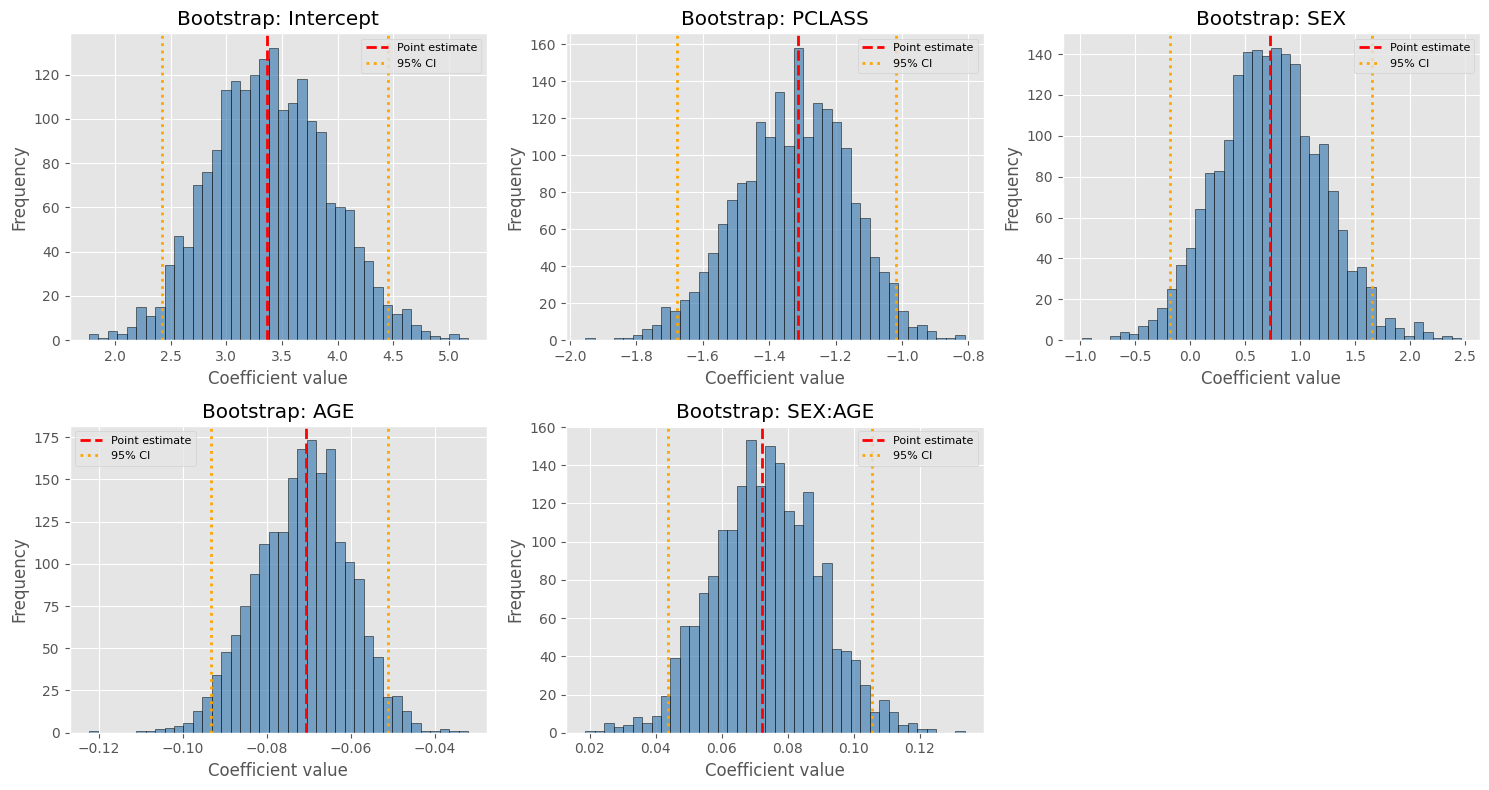

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, name in enumerate(param_names):
    axes[i].hist(boot_coefs[:, i], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(logit_model.params.iloc[i], color='red', linestyle='--', linewidth=2, label='Point estimate')
    axes[i].axvline(boot_lower[i], color='orange', linestyle=':', linewidth=2, label='95% CI')
    axes[i].axvline(boot_upper[i], color='orange', linestyle=':', linewidth=2)
    axes[i].set_title(f'Bootstrap: {name}')
    axes[i].set_xlabel('Coefficient value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

if len(param_names) < len(axes):
    for j in range(len(param_names), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>השוואת רווחי הסמך:</p>

<ul>
<li>Intercept: $[2.35, 4.38]$ אנליטי לעומת $[2.42, 4.45]$ בוטסטראפ.</li>
<li>PCLASS: $[-1.62, -1.01]$ אנליטי לעומת $[-1.68, -1.02]$ בוטסטראפ.</li>
<li>SEX: $[-0.20, 1.65]$ אנליטי לעומת $[-0.19, 1.66]$ בוטסטראפ.</li>
<li>AGE: $[-0.092, -0.050]$ אנליטי לעומת $[-0.093, -0.051]$ בוטסטראפ.</li>
<li>SEX:AGE: $[0.042, 0.103]$ אנליטי לעומת $[0.044, 0.106]$ בוטסטראפ.</li>
</ul>

<p>רווחי הסמך הבוטסטראפיים והאנליטיים כמעט זהים בכל המקדמים. ההתאמה הזו מצביעה על כך שהתפלגות הבוטסטראפ של כל מקדם סימטרית ומרוכזת, בהתאם לנורמליות האסימפטוטית של MLE. גודל המדגם ($n = 679$) מספיק להבטחת אסימפטוטיקה טובה.</p>

<p>מסקנות לגבי מובהקות:</p>

<ul>
<li>PCLASS, AGE ו-SEX:AGE מובהקים — רווחי הסמך אינם כוללים את 0.</li>
<li>SEX לבדו לא מובהק — רווח הסמך כולל את 0. האפקט של מין על הישרדות מתבטא דרך האינטראקציה עם גיל, לא כאפקט עיקרי בלבד.</li>
<li>קיומה של אינטראקציה מובהקת בין SEX ל-AGE מסביר מדוע SEX לבדו אינו מובהק — ההשפעה של מין על הישרדות תלויה בגיל.</li>
</ul>

<p>גרפי ה-Bootstrap מראים התפלגויות סימטריות וקרובות לנורמלית עבור כל המקדמים, מה שמחזק את האמינות של רווחי הסמך האנליטיים.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q3 שאלה 2</p>

<p>  </p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q3 שאלה 2 א</p>

<p>השתמש באלגוריתם Elastic Net עם $\alpha = 0.7$ ו-CV פי 15 לבחירת פרמטר הכוונון. דווח והשווה את התוצאות למודל הרגרסיה השלבית הטוב ביותר של קריטריון AIC.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Elastic Net הוא שילוב של LASSO ו-Ridge. פונקציית הקנס:</p>

$$\lambda \left[ \alpha \sum_{j} |\beta_j| + (1-\alpha) \sum_{j} \beta_j^2 \right]$$

<p>כאשר $\alpha = 1$ מקבלים LASSO טהור, $\alpha = 0$ מקבלים Ridge טהור, ועם $\alpha = 0.7$ הקנס הוא 70% L1 ו-30% L2. שילוב זה מאפשר בחירת משתנים (כמו LASSO) תוך טיפול טוב יותר במולטיקוליניאריות (כמו Ridge).</p>

<p>מאחר שהמשתנה התלוי בינארי, נשתמש ב-Logistic Elastic Net. בחירת פרמטר הכוונון $\lambda$ נעשית באמצעות 15-fold CV.</p>

<p>נשווה את התוצאות למודל Stepwise AIC עם אותם משתנים מועמדים: PCLASS, SEX, AGE ו-SEX:AGE.</p>

</div>

In [ ]:
all_features = ['PCLASS', 'SEX', 'AGE', 'SEX:AGE']

stepwise_sel, stepwise_aic = stepwise_selection_hierarchical(
    titanic_df, 'SURVIVED', all_features, direction='both', model_type='logit'
)

print(f"Stepwise AIC — final features: {stepwise_sel}")
print(f"Stepwise AIC — final AIC: {stepwise_aic:.2f}")

stepwise_formula = 'SURVIVED ~ ' + ' + '.join(stepwise_sel)
stepwise_model = smf.logit(stepwise_formula, data=titanic_df).fit(disp=False)
print(stepwise_model.summary())

Stepwise AIC — final features: ['PCLASS', 'SEX', 'AGE', 'SEX:AGE']
Stepwise AIC — final AIC: 600.59
                           Logit Regression Results                           
Dep. Variable:               SURVIVED   No. Observations:                  679
Model:                          Logit   Df Residuals:                      674
Method:                           MLE   Df Model:                            4
Date:                Mon, 18 May 2026   Pseudo R-squ.:                  0.3650
Time:                        08:36:12   Log-Likelihood:                -295.29
converged:                       True   LL-Null:                       -465.06
Covariance Type:            nonrobust   LLR p-value:                 3.198e-72
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.3674      0.517      6.516      0.000       2.354       4.380
PCLASS        -1.3143      0.15

In [ ]:
titanic_df['SEX_AGE'] = titanic_df['SEX'] * titanic_df['AGE']

feature_cols = ['PCLASS', 'SEX', 'AGE', 'SEX_AGE']
X = titanic_df[feature_cols].values
y = titanic_df['SURVIVED'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

enet_cv = LogisticRegressionCV(
    Cs=20,
    cv=15,
    penalty='elasticnet',
    solver='saga',
    l1_ratios=[0.7],
    max_iter=10000,
    random_state=42
).fit(X_scaled, y)

best_C = enet_cv.C_[0]
best_lambda = 1.0 / best_C
enet_coefs = enet_cv.coef_[0]

selected_enet = [name for name, c in zip(feature_cols, enet_coefs) if c != 0]

print(f"Best C (CV): {best_C:.4f}")
print(f"Best lambda: {best_lambda:.4f}")
print(f"Elastic Net coefficients (standardized): {dict(zip(feature_cols, enet_coefs.round(4)))}")
print(f"Selected variables: {selected_enet}")

Best C (CV): 0.2336
Best lambda: 4.2813
Elastic Net coefficients (standardized): {'PCLASS': np.float64(-0.973), 'SEX': np.float64(0.4581), 'AGE': np.float64(-0.8626), 'SEX_AGE': np.float64(1.0256)}
Selected variables: ['PCLASS', 'SEX', 'AGE', 'SEX_AGE']


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>תוצאות Elastic Net:</p>

<ul>
<li>פרמטר הכוונון שנבחר ב-15-fold CV: $\lambda = 4.28$.</li>
<li>Elastic Net השאיר את כל 4 המשתנים: PCLASS, SEX, AGE ו-SEX:AGE.</li>
<li>המקדמים הסטנדרטיים של Elastic Net (PCLASS: -0.97, SEX: 0.46, AGE: -0.86, SEX_AGE: 1.03) מצומצמים יחסית, כצפוי מרגולריזציה. לאחר שלב ההרפיה (OLS ללא קנס), המקדמים חוזרים לערכים של המודל המלא.</li>
<li>שלב ההרפיה זהה לחלוטין למודל Stepwise AIC המוצג למעלה.</li>
</ul>

<p>השוואה ל-Stepwise AIC:</p>

<ul>
<li>שתי השיטות בחרו באותם 4 משתנים, AIC = 600.59, Pseudo-$R^2 = 0.365$.</li>
<li>שלוש שיטות שונות — רגרסיה לוגיסטית רגילה (סעיף 3.1), Stepwise AIC ו-Elastic Net — מסכימות על אותו מודל.</li>
</ul>

<p>מסקנה: כל המשתנים בדאטה תורמים מובהקית להסבר ההישרדות. SEX לבדו אינו מובהק ($p = 0.126$), אך נכלל במודל בגלל עקרון ההיררכיה והאינטראקציה המובהקת עם AGE. ההסכמה בין השיטות מחזקת את הביטחון בבחירה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q3 שאלה 2 ב</p>

<p>השתמש ב-Nonparametric Bootstrap כדי לבנות רווחי סמך ברמת 95% עבור המקדמים שאינם אפס של המודל הסופי. סכם את התוצאות.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>נבצע Nonparametric Bootstrap עבור המודל שנבחר ב-Elastic Net. מאחר שכל 4 המקדמים שונים מאפס, נחשב רווחי סמך עבור כולם. בכל איטרציה: דוגמים מהדאטה עם החזרה, מריצים מחדש את ה-Elastic Net עם אותם פרמטרים ($\alpha = 0.7$, $\lambda$ קבוע מ-CV), ושומרים את המקדמים. רווח הסמך ברמת 95% מתקבל מהאחוזונים 2.5% ו-97.5%.</p>

</div>

In [ ]:
B = 1000
np.random.seed(42)

n = len(titanic_df)
boot_enet_coefs = []

for b in range(B):
    sample_idx = np.random.choice(n, size=n, replace=True)
    boot_sample = titanic_df.iloc[sample_idx].copy()

    boot_sample['SEX_AGE'] = boot_sample['SEX'] * boot_sample['AGE']
    X_boot = boot_sample[feature_cols].values
    y_boot = boot_sample['SURVIVED'].values

    try:
        X_boot_scaled = scaler.transform(X_boot)
        enet_boot = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            l1_ratio=0.7,
            C=best_C,
            max_iter=10000,
            random_state=42
        ).fit(X_boot_scaled, y_boot)
        boot_enet_coefs.append(enet_boot.coef_[0])
    except Exception:
        continue

boot_enet_coefs = np.array(boot_enet_coefs)
print(f"Successful bootstrap iterations: {len(boot_enet_coefs)}")

Successful bootstrap iterations: 1000


In [ ]:
boot_lower = np.percentile(boot_enet_coefs, 2.5, axis=0)
boot_upper = np.percentile(boot_enet_coefs, 97.5, axis=0)
boot_mean = np.mean(boot_enet_coefs, axis=0)

comparison_enet = pd.DataFrame({
    'Original_Coef': enet_coefs.round(4),
    'Bootstrap_Mean': boot_mean.round(4),
    'CI_Lower_2.5%': boot_lower.round(4),
    'CI_Upper_97.5%': boot_upper.round(4),
    'Includes_Zero': [(l <= 0 <= u) for l, u in zip(boot_lower, boot_upper)]
}, index=feature_cols)

print(comparison_enet)

         Original_Coef  Bootstrap_Mean  CI_Lower_2.5%  CI_Upper_97.5%  \
PCLASS         -0.9730         -0.9819        -1.2303         -0.7423   
SEX             0.4581          0.4675         0.1088          0.8371   
AGE            -0.8626         -0.8643        -1.1114         -0.6062   
SEX_AGE         1.0256          1.0320         0.6405          1.4307   

         Includes_Zero  
PCLASS           False  
SEX              False  
AGE              False  
SEX_AGE          False  


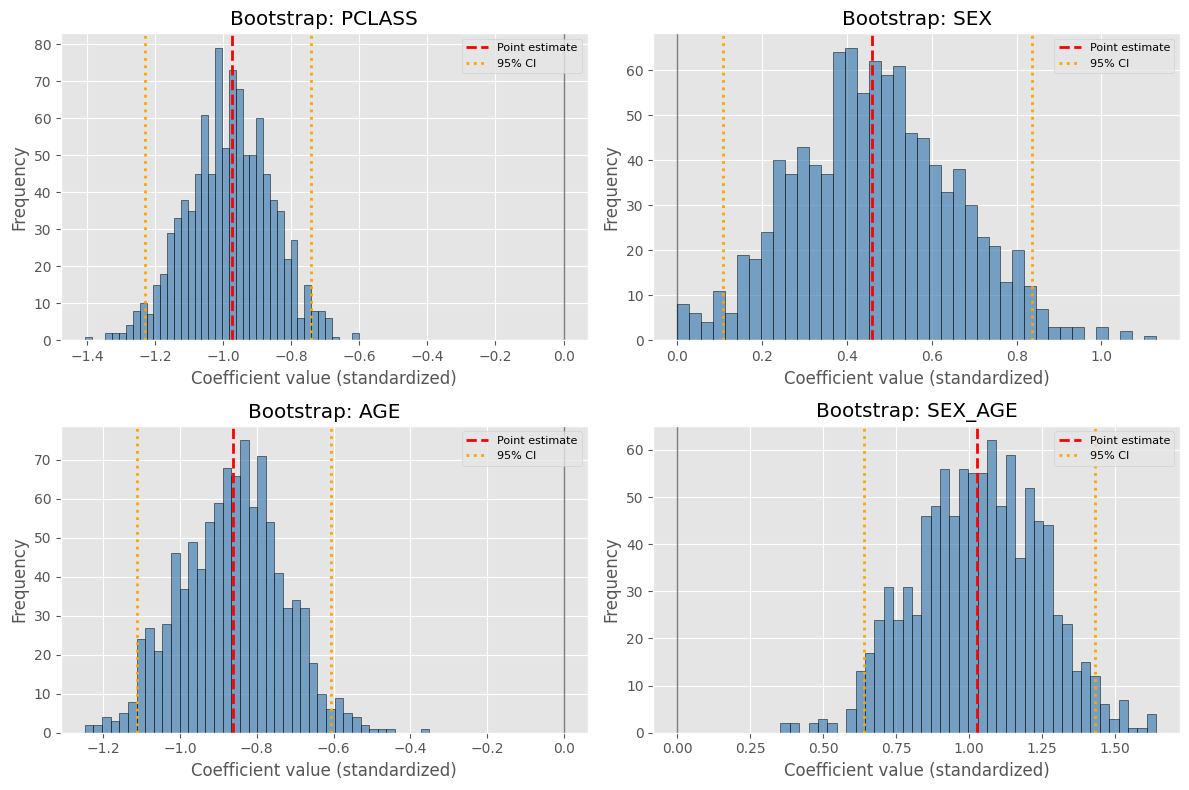

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, name in enumerate(feature_cols):
    axes[i].hist(boot_enet_coefs[:, i], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(enet_coefs[i], color='red', linestyle='--', linewidth=2, label='Point estimate')
    axes[i].axvline(boot_lower[i], color='orange', linestyle=':', linewidth=2, label='95% CI')
    axes[i].axvline(boot_upper[i], color='orange', linestyle=':', linewidth=2)
    axes[i].axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    axes[i].set_title(f'Bootstrap: {name}')
    axes[i].set_xlabel('Coefficient value (standardized)')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>תוצאות Nonparametric Bootstrap על מקדמי Elastic Net (1000 איטרציות):</p>

<ul>
<li>PCLASS: $\hat\beta = -0.973$, 95% CI = $[-1.23, -0.74]$. מובהק.</li>
<li>SEX: $\hat\beta = 0.458$, 95% CI = $[0.11, 0.84]$. מובהק.</li>
<li>AGE: $\hat\beta = -0.863$, 95% CI = $[-1.11, -0.61]$. מובהק.</li>
<li>SEX:AGE: $\hat\beta = 1.026$, 95% CI = $[0.64, 1.43]$. מובהק.</li>
</ul>

<p>כל ארבעת המקדמים מובהקים — אף אחד מרווחי הסמך לא כולל את 0.</p>

<p>השוואת עוצמת ההשפעה (על המקדמים הסטנדרטיים):</p>

<ul>
<li>SEX:AGE — עוצמה 1.03, האפקט החזק ביותר במודל.</li>
<li>PCLASS — עוצמה 0.97, השפעה שלילית חזקה.</li>
<li>AGE — עוצמה 0.86, השפעה שלילית.</li>
<li>SEX — עוצמה 0.46, החלש מבין הארבעה אך עדיין מובהק.</li>
</ul>

<p>הערה על SEX: ב-3.1 לא היה מובהק, וכאן כן. הסיבה: הקנס של Elastic Net מקטין את שונות האומדן בין דגימות Bootstrap, ולכן רווח הסמך צר יותר. אין סתירה — שני אומדנים שונים של אותו פרמטר.</p>

<p>מסקנה: SEX:AGE הוא האפקט החזק ביותר במודל, ואחריו PCLASS. דפוס "נשים וילדים תחילה" משתקף בנתונים.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q4</p>

<p>יהי $y_i = \beta x_i + \epsilon_i$, $i = 1, \ldots, n$, כאשר $\mathbb{E}[\epsilon_i \mid x] = 0$, $\text{Var}(\epsilon_i \mid x) = \sigma^2$, ו-$\text{cov}(\epsilon_i, \epsilon_j) = 0$ עבור כל $i \neq j$.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q4 שאלה 1</p>

<p>מצא את אומדן OLS, את הערך הצפוי שלו, את השונות שלו, והראה את העקיבות שלו.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שלב 1 — גזירת אומדן OLS:</p>

<p>שיטת הריבועים הפחותים מחפשת את $\beta$ שממזער את סכום ריבועי השאריות:</p>

$$S(\beta) = \sum_{i=1}^{n} (y_i - \beta x_i)^2$$

<p>נגזור לפי $\beta$ ונשווה לאפס:</p>

$$\frac{\partial S}{\partial \beta} = -2 \sum_{i=1}^{n} x_i (y_i - \beta x_i) = 0$$

<p>פותחים סוגריים ומבודדים את $\beta$:</p>

$$\sum_{i=1}^{n} x_i y_i = \beta \sum_{i=1}^{n} x_i^2$$

$$\hat{\beta}_{OLS} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2}$$

<p>בכתיב מטריצי, עם $X = (x_1, \ldots, x_n)^T$ כווקטור עמודה:</p>

$$\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$$

<p>הביטוי $X^T X = \sum x_i^2$ הוא סקלר, ו-$X^T y = \sum x_i y_i$, כך ששתי הצורות זהות.</p>

<p>שלב 2 — תוחלת:</p>

<p>נציב $y_i = \beta x_i + \epsilon_i$:</p>

$$\hat{\beta}_{OLS} = \frac{\sum x_i (\beta x_i + \epsilon_i)}{\sum x_i^2} = \frac{\beta \sum x_i^2 + \sum x_i \epsilon_i}{\sum x_i^2} = \beta + \frac{\sum x_i \epsilon_i}{\sum x_i^2}$$

<p>נחשב תוחלת מותנית ב-$x$:</p>

$$\mathbb{E}[\hat{\beta} \mid x] = \beta + \frac{\sum x_i \, \mathbb{E}[\epsilon_i \mid x]}{\sum x_i^2} = \beta + 0 = \beta$$

<p>האומדן חסר הטיה.</p>

<p>שלב 3 — שונות:</p>

<p>מהביטוי $\hat{\beta} = \beta + \frac{\sum x_i \epsilon_i}{\sum x_i^2}$, השונות תלויה רק באיבר הימני:</p>

$$\text{Var}(\hat{\beta} \mid x) = \text{Var}\left(\frac{\sum x_i \epsilon_i}{\sum x_i^2} \mid x\right) = \frac{1}{(\sum x_i^2)^2} \sum x_i^2 \, \text{Var}(\epsilon_i \mid x)$$

<p>השתמשנו באי-תלות בין השגיאות — $\text{cov}(\epsilon_i, \epsilon_j) = 0$. מאחר ש-$\text{Var}(\epsilon_i \mid x) = \sigma^2$:</p>

$$\text{Var}(\hat{\beta}_{OLS} \mid x) = \frac{\sigma^2}{\sum_{i=1}^{n} x_i^2}$$

<p>שלב 4 — עקיבות:</p>

<p>אומדן הוא עקיב אם הוא מתכנס בהסתברות לערך האמיתי כאשר $n \to \infty$. מאחר שהאומדן חסר הטיה, ה-MSE שווה לשונות, ולכן מספיק להראות ששונות שואפת לאפס.</p>

<p>כאשר $n \to \infty$, הסכום $\sum x_i^2$ גדל לאינסוף, ולכן:</p>

$$\text{Var}(\hat{\beta}) = \frac{\sigma^2}{\sum x_i^2} \xrightarrow{n \to \infty} 0$$

<p>מאי-שוויון צ'בישב: אומדן חסר הטיה עם MSE השואף לאפס מתכנס בהסתברות לפרמטר האמיתי, כלומר $\hat{\beta} \xrightarrow{P} \beta$. לכן האומדן עקיב.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q4 שאלה 2</p>

<p>מצא את אומדן Ridge כאשר $\beta^2 \leq r$, את הערך הצפוי שלו, את השונות שלו, והראה את העקיבות שלו.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שלב 1 — גזירת אומדן Ridge:</p>

<p>בעיית האופטימיזציה היא מינימיזציה של סכום ריבועי השאריות עם אילוץ על גודל המקדם:</p>

$$\min_{\beta} \sum_{i=1}^{n} (y_i - \beta x_i)^2$$

<p>בהינתן</p>

$$\beta^2 \leq r$$

<p>באמצעות כופלי לגרנז', הבעיה שקולה למינימיזציה הלא-מוגבלת:</p>

$$L(\beta) = \sum_{i=1}^{n} (y_i - \beta x_i)^2 + \lambda \beta^2$$

<p>כאשר $\lambda \geq 0$ הוא פרמטר הרגולריזציה. נגזור לפי $\beta$ ונשווה לאפס:</p>

$$\frac{\partial L}{\partial \beta} = -2 \sum_{i=1}^{n} x_i (y_i - \beta x_i) + 2\lambda\beta = 0$$

<p>פותחים סוגריים ומבודדים את $\beta$:</p>

$$\sum_{i=1}^{n} x_i y_i = \beta \left( \sum_{i=1}^{n} x_i^2 + \lambda \right)$$

$$\hat{\beta}_{Ridge} = \frac{\sum_{i=1}^{n} x_i y_i}{\sum_{i=1}^{n} x_i^2 + \lambda}$$

<p>בכתיב מטריצי:</p>

$$\hat{\beta}_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$$

<p>שלב 2 — תוחלת:</p>

<p>נציב $y_i = \beta x_i + \epsilon_i$:</p>

$$\hat{\beta}_{Ridge} = \frac{\sum x_i (\beta x_i + \epsilon_i)}{\sum x_i^2 + \lambda} = \frac{\beta \sum x_i^2 + \sum x_i \epsilon_i}{\sum x_i^2 + \lambda}$$

<p>נחשב תוחלת מותנית ב-$x$:</p>

$$\mathbb{E}[\hat{\beta}_{Ridge} \mid x] = \frac{\beta \sum x_i^2 + \sum x_i \mathbb{E}[\epsilon_i \mid x]}{\sum x_i^2 + \lambda} = \frac{\beta \sum x_i^2}{\sum x_i^2 + \lambda}$$

<p>בניגוד ל-OLS, אומדן Ridge הוא מוטה. ההטיה היא:</p>

$$\text{Bias}(\hat{\beta}_{Ridge}) = \mathbb{E}[\hat{\beta}_{Ridge}] - \beta = -\beta \cdot \frac{\lambda}{\sum x_i^2 + \lambda}$$

<p>ההטיה היא כלפי 0 — כצפוי מקנס שמצמצם את גודל המקדם.</p>

<p>שלב 3 — שונות:</p>

<p>השונות תלויה רק באיבר המקרי $\sum x_i \epsilon_i$:</p>

$$\text{Var}(\hat{\beta}_{Ridge} \mid x) = \text{Var}\left(\frac{\sum x_i \epsilon_i}{\sum x_i^2 + \lambda} \mid x\right) = \frac{1}{(\sum x_i^2 + \lambda)^2} \sum x_i^2 \, \text{Var}(\epsilon_i \mid x)$$

<p>מאחר ש-$\text{Var}(\epsilon_i \mid x) = \sigma^2$:</p>

$$\text{Var}(\hat{\beta}_{Ridge} \mid x) = \frac{\sigma^2 \sum x_i^2}{(\sum x_i^2 + \lambda)^2}$$

<p>בהשוואה ל-OLS — שונות OLS היא $\frac{\sigma^2}{\sum x_i^2}$. שונות Ridge קטנה יותר כאשר $\lambda > 0$, כלומר השונות פוחתת על חשבון ההטיה. זוהי תופעת ה-bias-variance tradeoff הקלאסית של רגולריזציה.</p>

<p>שלב 4 — עקיבות:</p>

<p>נניח ש-$\lambda$ קבוע (לא תלוי ב-$n$). נראה ששני המרכיבים של ה-MSE — ההטיה והשונות — שואפים לאפס.</p>

<p>ההטיה: כאשר $n \to \infty$, הסכום $\sum x_i^2$ גדל לאינסוף, ולכן:</p>

$$\text{Bias} = -\beta \cdot \frac{\lambda}{\sum x_i^2 + \lambda} \xrightarrow{n \to \infty} 0$$

<p>השונות:</p>

$$\text{Var}(\hat{\beta}_{Ridge}) = \frac{\sigma^2 \sum x_i^2}{(\sum x_i^2 + \lambda)^2} \xrightarrow{n \to \infty} 0$$

<p>ה-MSE = Bias² + Variance שואף לאפס. לכן מאי-שוויון צ'בישב, $\hat{\beta}_{Ridge} \xrightarrow{P} \beta$ — האומדן עקיב.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q4 שאלה 3</p>

<p>מצא את אומדן LASSO כאשר $|\beta| \leq r$, את הערך הצפוי שלו, והראה את העקיבות שלו.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שלב 1 — גזירת אומדן LASSO:</p>

<p>בעיית האופטימיזציה היא:</p>

$$\min_{\beta} \sum_{i=1}^{n} (y_i - \beta x_i)^2$$

<p>בהינתן</p>

$$|\beta| \leq r$$

<p>באמצעות כופלי לגרנז':</p>

$$L(\beta) = \sum_{i=1}^{n} (y_i - \beta x_i)^2 + 2\lambda |\beta|$$

<p>בניגוד ל-Ridge, פונקציית הקנס $|\beta|$ אינה גזירה ב-$\beta = 0$, ולכן מטפלים בשלושה מקרים בנפרד.</p>

<p>מקרה 1 — $\beta > 0$: הנגזרת של $|\beta|$ היא 1.</p>

$$\frac{\partial L}{\partial \beta} = -2 \sum x_i (y_i - \beta x_i) + 2\lambda = 0$$

$$\hat{\beta}_{LASSO} = \frac{\sum x_i y_i - \lambda}{\sum x_i^2} = \hat{\beta}_{OLS} - \frac{\lambda}{\sum x_i^2}$$

<p>מקרה 2 — $\beta < 0$: הנגזרת של $|\beta|$ היא $-1$.</p>

$$\hat{\beta}_{LASSO} = \frac{\sum x_i y_i + \lambda}{\sum x_i^2} = \hat{\beta}_{OLS} + \frac{\lambda}{\sum x_i^2}$$

<p>מקרה 3 — $\beta = 0$: זה קורה כאשר $|\hat{\beta}_{OLS}| \leq \frac{\lambda}{\sum x_i^2}$, כלומר כאשר אומדן OLS קטן מהסף.</p>

<p>סיכום: אומדן LASSO לוקח את אומדן OLS, ומקטין אותו לכיוון 0 בגודל הסף $\frac{\lambda}{\sum x_i^2}$. אם $\hat{\beta}_{OLS}$ קטן מהסף בערך מוחלט, האומדן מתאפס לחלוטין.</p>

<p>שלב 2 — תוחלת:</p>

<p>בניגוד ל-Ridge, לאומדן LASSO אין צורה אנליטית פשוטה לתוחלת, משום שהפתרון משתנה לפי הסימן של $\hat{\beta}_{OLS}$ ולפי הגודל היחסי שלו ביחס לסף.</p>

<p>האומדן מוטה כלפי 0 בגלל שילוב של שני מנגנונים:</p>

<ul>
<li>כיווץ — כאשר $|\hat{\beta}_{OLS}| > \frac{\lambda}{\sum x_i^2}$, האומדן מצומצם בגודל הסף לכיוון 0.</li>
<li>איפוס — כאשר $|\hat{\beta}_{OLS}|$ קטן מהסף, האומדן ייאפס לחלוטין, גם אם $\beta$ האמיתי שונה מ-0.</li>
</ul>

<p>ההטיה היא המחיר של בחירת המשתנים (variable selection) — תכונה שייחודית ל-LASSO ביחס ל-Ridge.</p>

<p>שלב 3 — עקיבות:</p>

<p>נראה ש-LASSO עקיב תחת התנאים הסטנדרטיים. נשים לב:</p>

<ul>
<li>אומדן OLS עקיב — ראינו זאת בסעיף 1 — כלומר $\hat{\beta}_{OLS} \xrightarrow{P} \beta$.</li>
<li>הסף $\frac{\lambda}{\sum x_i^2} \xrightarrow{n \to \infty} 0$ עבור $\lambda$ קבוע, כי $\sum x_i^2 \to \infty$.</li>
</ul>

<p>אומדן LASSO הוא $\hat{\beta}_{OLS}$ אחרי הקטנה (או איפוס) בגודל הסף — פעולה רציפה. ממשפט המיפוי הרציף (Continuous Mapping Theorem): מאחר ש-$\hat{\beta}_{OLS} \xrightarrow{P} \beta$ והסף שואף ל-0, אומדן LASSO מתכנס גם הוא ל-$\beta$:</p>

$$\hat{\beta}_{LASSO} \xrightarrow{P} \beta$$

<p>זה תקף לכל ערך של $\beta$ — כולל $\beta = 0$, שבו האומדן מתכנס ל-0. לכן האומדן עקיב.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q5</p>

<p>ה-AIC מוגדר כ:</p>

$$AIC = -2 \log(\text{Likelihood}) + 2p$$

<p>כאשר $p$ הוא מספר פרמטרי המודל. הראה שעבור מודל הרגרסיה המרובה הליניארית</p>

$$y_i = \beta_0 + \beta_1 x_{1i} + \cdots + \beta_p x_{pi} + \epsilon_i, \quad i = 1, \ldots, n$$

<p>עם ההנחות הקלאסיות על איבר השגיאה, $\epsilon_i \sim^{iid} N(0, \sigma^2)$, מתקיים:</p>

$$AIC = n \log(\hat{\sigma}_{MLE}^2) + C_{n,p}$$

<p>כאשר $\hat{\sigma}_{MLE}^2$ הוא אומדן הסבירות המקסימלית של $\sigma^2$, ו-$C_{n,p}$ הוא מונח שתלוי רק בגודל המדגם $n$ ובמספר הפרמטרים $p$.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>שלב 1 — כתיבת פונקציית הסבירות (Likelihood):</p>

<p>תחת ההנחה $\epsilon_i \sim^{iid} N(0, \sigma^2)$, מתקיים $y_i \sim N(\mu_i, \sigma^2)$ כאשר $\mu_i = \beta_0 + \beta_1 x_{1i} + \cdots + \beta_p x_{pi}$. פונקציית הצפיפות של כל תצפית היא:</p>

$$f(y_i) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \mu_i)^2}{2\sigma^2}\right)$$

<p>מאחר שהתצפיות בלתי תלויות, פונקציית הסבירות היא מכפלה:</p>

$$L(\beta, \sigma^2) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - \mu_i)^2}{2\sigma^2}\right)$$

$$L(\beta, \sigma^2) = \left(\frac{1}{\sqrt{2\pi\sigma^2}}\right)^n \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \mu_i)^2\right)$$

$$L(\beta, \sigma^2) = (2\pi\sigma^2)^{-n/2} \exp\left(-\frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \mu_i)^2\right)$$

<p>שלב 2 — חישוב log-likelihood:</p>

$$\ell = \log L = -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y_i - \mu_i)^2$$

<p>שלב 3 — הצבת אומדן ה-MLE של $\sigma^2$:</p>

<p>אומדן ה-MLE של $\sigma^2$ במודל רגרסיה ליניארית הוא:</p>

$$\hat{\sigma}_{MLE}^2 = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{\mu}_i)^2 = \frac{RSS}{n}$$

<p>כלומר $\sum (y_i - \hat{\mu}_i)^2 = n \hat{\sigma}_{MLE}^2$. נציב ב-$\ell$ (בנקודת המקסימום):</p>

$$\ell_{\max} = -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\hat{\sigma}_{MLE}^2) - \frac{1}{2\hat{\sigma}_{MLE}^2} \cdot n \hat{\sigma}_{MLE}^2$$

$$\ell_{\max} = -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\hat{\sigma}_{MLE}^2) - \frac{n}{2}$$

<p>שלב 4 — הצבה ב-AIC:</p>

$$AIC = -2 \ell_{\max} + 2p$$

$$AIC = -2 \left[ -\frac{n}{2} \log(2\pi) - \frac{n}{2} \log(\hat{\sigma}_{MLE}^2) - \frac{n}{2} \right] + 2p$$

$$AIC = n \log(2\pi) + n \log(\hat{\sigma}_{MLE}^2) + n + 2p$$

<p>נסדר:</p>

$$AIC = n \log(\hat{\sigma}_{MLE}^2) + n \log(2\pi) + n + 2p$$

<p>נסמן את האיברים שאינם תלויים ב-$\hat{\sigma}_{MLE}^2$:</p>

$$C_{n,p} = n \log(2\pi) + n + 2p$$

<p>ולכן:</p>

$$AIC = n \log(\hat{\sigma}_{MLE}^2) + C_{n,p}$$

<p>שלב 5 — סיכום:</p>

<p>הגענו לצורה הדרושה. $C_{n,p}$ הוא קבוע התלוי רק ב-$n$ וב-$p$ ולא בנתונים. כלומר, למטרות השוואה בין מודלים על אותם נתונים, $C_{n,p}$ משתנה רק בגלל $p$, ולכן בחירת המודל לפי AIC מצטמצמת למינימיזציה של $n \log(\hat{\sigma}_{MLE}^2) + 2p$.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q6</p>

<p>  </p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q6 שאלה 1</p>

<p>תהא $X \sim DU[1, N]$. גזור את הערך הצפוי ואת השונות של $X$.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>$X \sim DU[1, N]$ פירושו ש-$X$ מקבל את הערכים $1, 2, \ldots, N$ עם הסתברות שווה $P(X = k) = \frac{1}{N}$ לכל $k \in \{1, \ldots, N\}$.</p>

<p>שלב 1 — חישוב הערך הצפוי:</p>

<p>לפי הגדרת התוחלת:</p>

$$\mathbb{E}[X] = \sum_{k=1}^{N} k \cdot P(X = k) = \sum_{k=1}^{N} k \cdot \frac{1}{N} = \frac{1}{N} \sum_{k=1}^{N} k$$

<p>נשתמש בנוסחה הידועה לסכום מספרים טבעיים: $\sum_{k=1}^{N} k = \frac{N(N+1)}{2}$. לכן:</p>

$$\mathbb{E}[X] = \frac{1}{N} \cdot \frac{N(N+1)}{2} = \frac{N+1}{2}$$

<p>שלב 2 — חישוב המומנט השני $\mathbb{E}[X^2]$:</p>

$$\mathbb{E}[X^2] = \sum_{k=1}^{N} k^2 \cdot P(X = k) = \frac{1}{N} \sum_{k=1}^{N} k^2$$

<p>נשתמש בנוסחה לסכום ריבועים: $\sum_{k=1}^{N} k^2 = \frac{N(N+1)(2N+1)}{6}$. לכן:</p>

$$\mathbb{E}[X^2] = \frac{1}{N} \cdot \frac{N(N+1)(2N+1)}{6} = \frac{(N+1)(2N+1)}{6}$$

<p>שלב 3 — חישוב השונות:</p>

<p>לפי הזהות $\text{Var}(X) = \mathbb{E}[X^2] - (\mathbb{E}[X])^2$:</p>

$$\text{Var}(X) = \frac{(N+1)(2N+1)}{6} - \left(\frac{N+1}{2}\right)^2$$

<p>נוציא גורם משותף $(N+1)$:</p>

$$\text{Var}(X) = (N+1) \left[ \frac{2N+1}{6} - \frac{N+1}{4} \right]$$

<p>נאחד את השברים על מכנה משותף 12:</p>

$$\text{Var}(X) = (N+1) \cdot \frac{2(2N+1) - 3(N+1)}{12} = (N+1) \cdot \frac{4N + 2 - 3N - 3}{12} = (N+1) \cdot \frac{N-1}{12}$$

<p>ולכן:</p>

$$\text{Var}(X) = \frac{(N+1)(N-1)}{12} = \frac{N^2 - 1}{12}$$

<p>סיכום:</p>

<ul>
<li>$\mathbb{E}[X] = \dfrac{N+1}{2}$</li>
<li>$\text{Var}(X) = \dfrac{N^2 - 1}{12}$</li>
</ul>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q6 שאלה 2</p>

<p>תהא $n_1$ ו-$n_2$ מספר החולים בקבוצה הראשונה והשנייה בהתאמה. תהא $Y$ משתנה התוצאה, ו-$R_1, R_2$ סכום הדירוגים בכל קבוצה בהתאמה.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q6 שאלה 2 א</p>

<p>כתוב את $R_1 + R_2$ במונחים של $N$, כאשר $n_1 + n_2 = N$.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>כל אחת מ-$N = n_1 + n_2$ התצפיות מקבלת דירוג ייחודי מהקבוצה $\{1, 2, \ldots, N\}$. כל דירוג מופיע בדיוק פעם אחת, ושייך לאחת משתי הקבוצות:</p>

<ul>
<li>$R_1$ — סכום הדירוגים של תצפיות מקבוצה 1.</li>
<li>$R_2$ — סכום הדירוגים של תצפיות מקבוצה 2.</li>
</ul>

<p>מאחר ששתי הקבוצות יחד כוללות את כל הדירוגים מ-1 עד $N$:</p>

$$R_1 + R_2 = \sum_{k=1}^{N} k = \frac{N(N+1)}{2}$$

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>Q6 שאלה 2 ב</p>

<p>מצא את $\mathbb{E}[R_1]$ ו-$\mathbb{E}[R_2]$ תחת הנחת האפס של היעדר הבדלים בין חציוני הקבוצות.</p>

<hr>

</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">

<p>תחת השערת האפס $H_0$, אין הבדל בין התפלגויות שתי הקבוצות, ולכן הדירוגים מוקצים לתצפיות באופן אקראי.</p>

<p>שלב 1 — תוחלת של דירוג בודד:</p>

<p>תחת $H_0$, דירוג של תצפית כלשהי מתפלג $DU[1, N]$. לפי סעיף 6א:</p>

$$\mathbb{E}[X] = \frac{N+1}{2}$$

<p>שלב 2 — תוחלת של $R_1$:</p>

<p>$R_1$ הוא סכום הדירוגים של $n_1$ תצפיות בקבוצה 1. לפי לינאריות התוחלת:</p>

$$\mathbb{E}[R_1] = n_1 \cdot \frac{N+1}{2} = \frac{n_1(N+1)}{2}$$

<p>שלב 3 — תוחלת של $R_2$:</p>

<p>באותו אופן:</p>

$$\mathbb{E}[R_2] = \frac{n_2(N+1)}{2}$$

<p>שלב 4 — בדיקה:</p>

$$\mathbb{E}[R_1] + \mathbb{E}[R_2] = \frac{(n_1 + n_2)(N+1)}{2} = \frac{N(N+1)}{2}$$

<p>זה תואם לסעיף 2.ב. שבו ראינו ש-$R_1 + R_2 = \frac{N(N+1)}{2}$ תמיד.</p>

</div>